<a href="https://colab.research.google.com/github/Anthony18xd/consumo_electrico/blob/main/consumo_el%C3%A9ctrico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ANÁLISIS DEL CONSUMO ELÉCTRICO RESIDENCIAL - ElectroPerú Hogares

📊 EXPLORACIÓN INICIAL DE DATOS
--------------------------------------------------------------------------------
Total de hogares analizados: 50

Primeras 10 observaciones:
   consumo_kwh
0          112
1           98
2          135
3          120
4          154
5          180
6          165
7           90
8          104
9          118

Últimas 10 observaciones:
    consumo_kwh
40          188
41           97
42          113
43          124
44          136
45          147
46          159
47          171
48          183
49           92

📋 INFORMACIÓN DEL DATASET
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   consumo_kwh  50 non-null     int64
dtypes: int64(1)
memory usage: 532.0 bytes
None

🔍 VERIFICACIÓN 

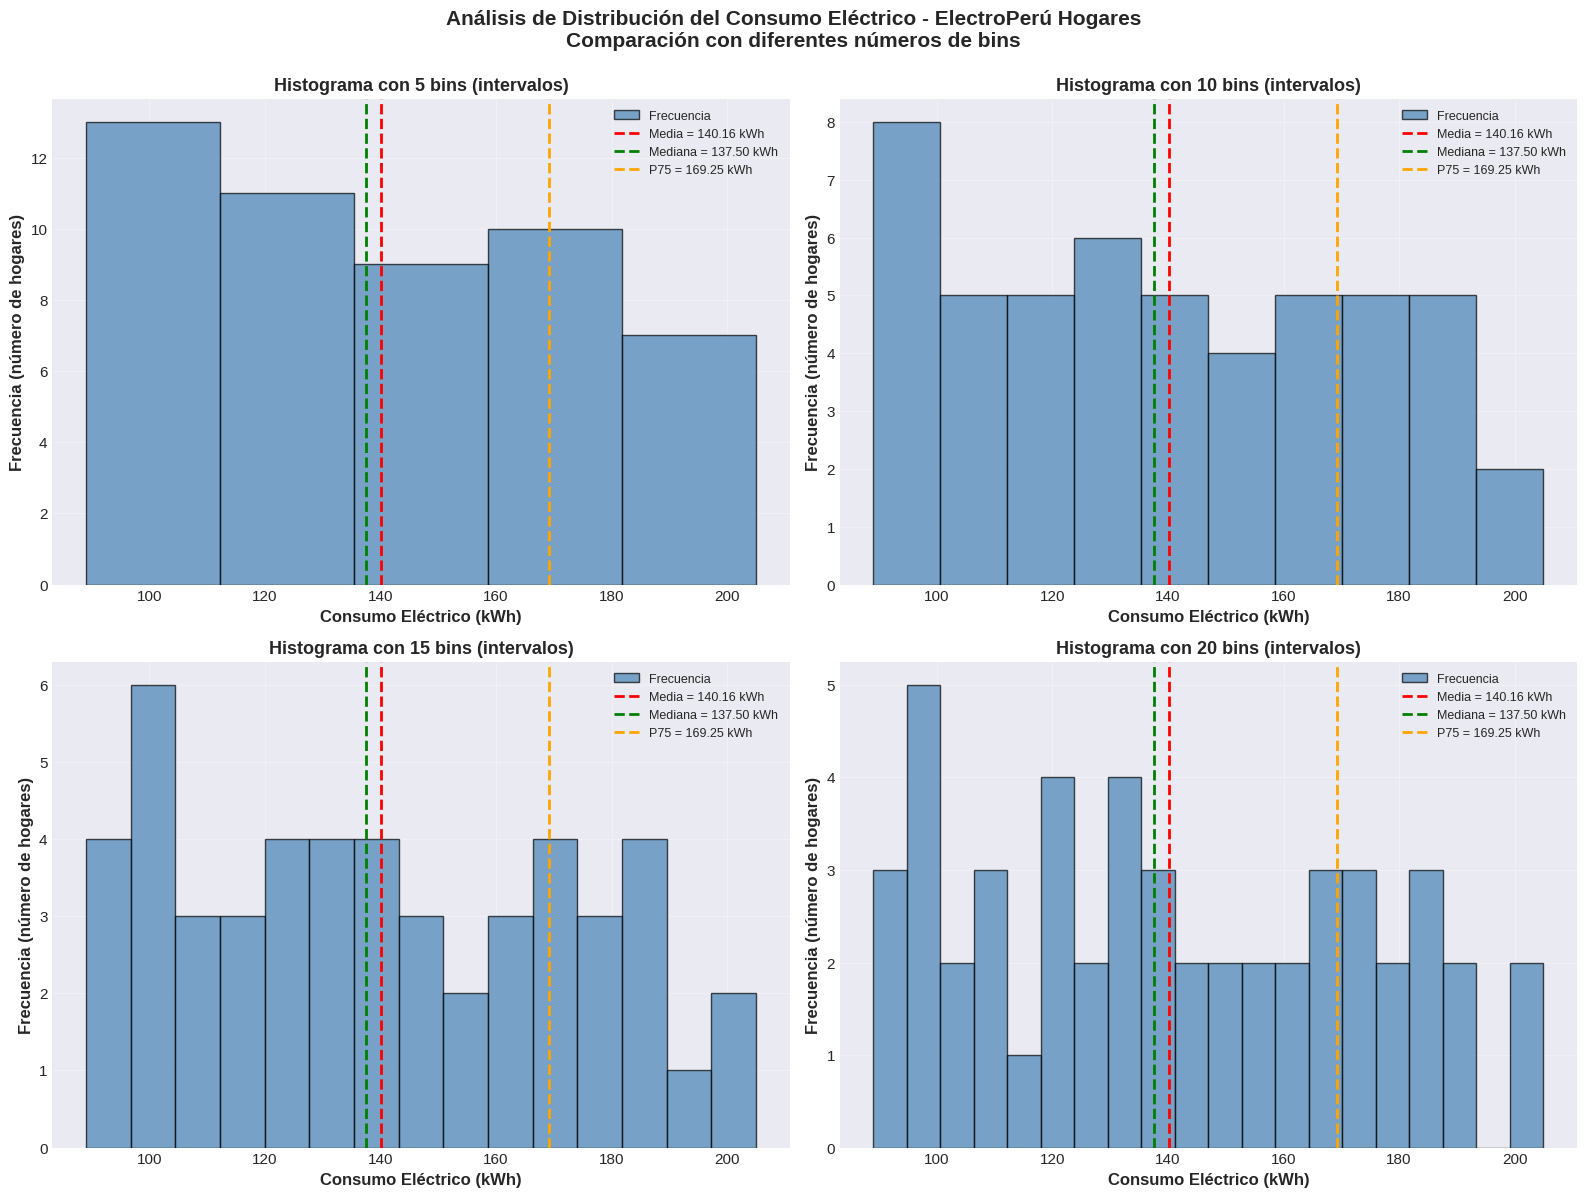

✓ Gráfico 1: Comparación de histogramas guardado


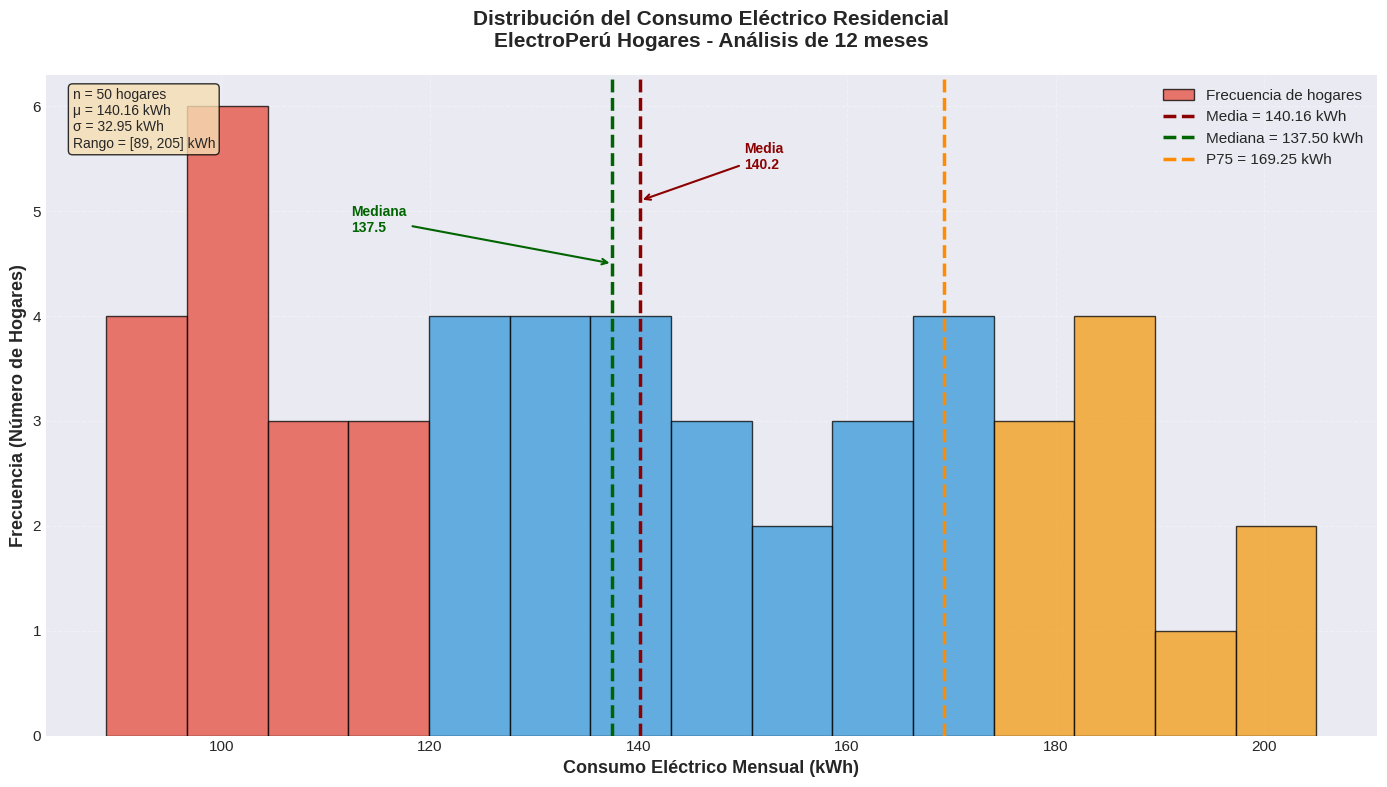

✓ Gráfico 2: Histograma principal guardado


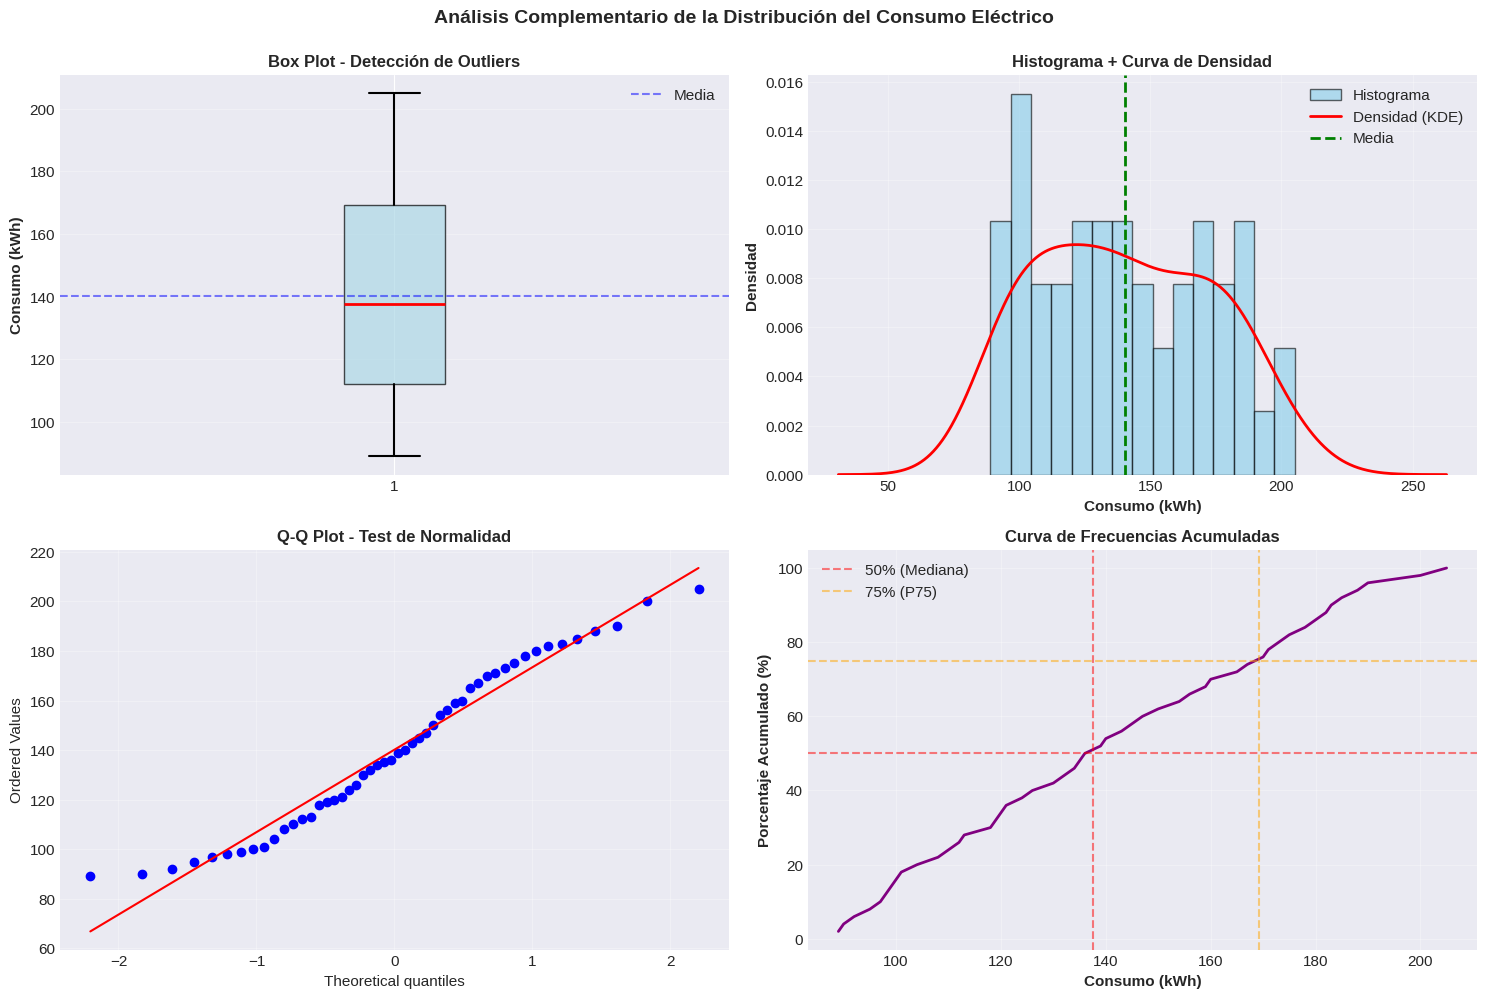

✓ Gráfico 3: Análisis complementario guardado

📋 CATEGORIZACIÓN DEL CONSUMO
--------------------------------------------------------------------------------

Distribución por categorías:
Bajo  :  13 hogares ( 26.0%)
Medio :  24 hogares ( 48.0%)
Alto  :  13 hogares ( 26.0%)


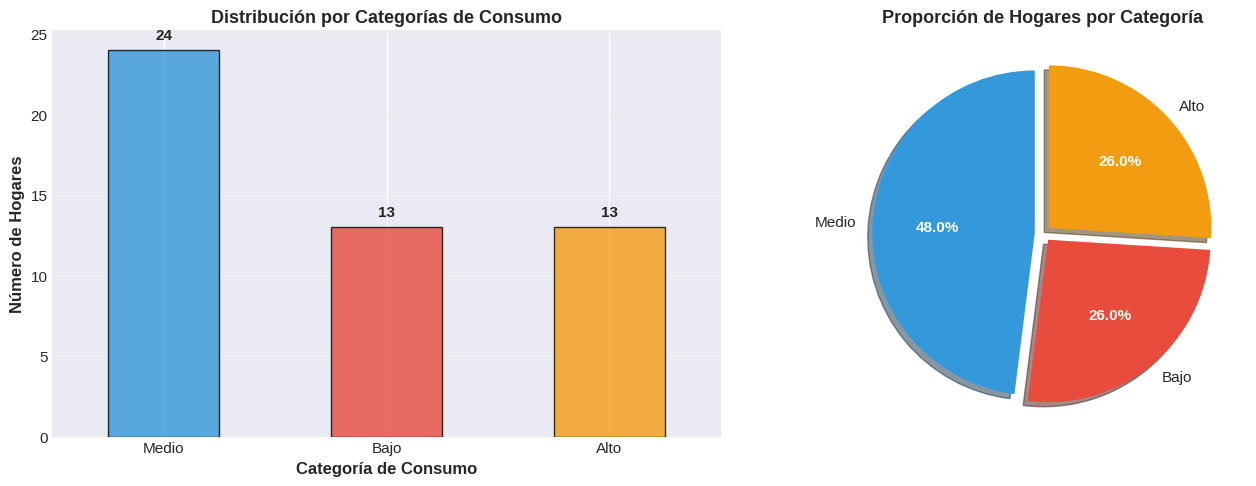

✓ Gráfico 4: Categorización guardado

📌 CONCLUSIONES DEL ANÁLISIS

1️⃣ CONCENTRACIÓN DEL CONSUMO:
   • La distribución es heterogénea entre las categorías

2️⃣ SIMETRÍA DE LA DISTRIBUCIÓN:
   • La distribución es APROXIMADAMENTE SIMÉTRICA (asimetría = 0.155)
   • Media (140.16) y mediana (137.50) son muy similares

3️⃣ VALORES ATÍPICOS (OUTLIERS):
   • NO se detectaron valores atípicos significativos
   • El consumo de todos los hogares está dentro de rangos esperados

4️⃣ VARIABILIDAD DEL CONSUMO:
   • Coeficiente de variación: 23.51%
   • Variabilidad MODERADA - Consumos relativamente consistentes

5️⃣ INTERPRETACIÓN DE PERCENTILES:
   • 25% de hogares consume MENOS de 112 kWh (consumo bajo)
   • 50% de hogares consume MENOS de 138 kWh (consumo bajo-medio)
   • 75% de hogares consume MENOS de 169 kWh (referencia para alto consumo)
   • Solo el 25% superior consume más de 169 kWh

💡 RECOMENDACIONES PARA ELECTROPERÚ HOGARES

🎯 SEGMENTACIÓN DE CLIENTES:
   • Consumo BAJO (<112 kWh): Pro

In [1]:
"""
ANÁLISIS DEL COMPORTAMIENTO MENSUAL DEL CONSUMO ELÉCTRICO DE HOGARES
ElectroPerú Hogares - Estudio de Consumo Residencial

Autor: Análisis de Datos
Fecha: 2026
Descripción: Análisis del consumo eléctrico utilizando histogramas para identificar
patrones de distribución, valores atípicos y estadísticos clave.
"""

# ============================================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 11

# ============================================================================
# 2. CARGA Y EXPLORACIÓN DE DATOS
# ============================================================================

print("=" * 80)
print("ANÁLISIS DEL CONSUMO ELÉCTRICO RESIDENCIAL - ElectroPerú Hogares")
print("=" * 80)

# Cargar datos (asegúrate de subir el archivo consumo_kwh.csv a Colab)
# En Google Colab, primero sube el archivo o usa:
# from google.colab import files
# uploaded = files.upload()

df = pd.read_csv('consumo_kwh.csv')

print("\n📊 EXPLORACIÓN INICIAL DE DATOS")
print("-" * 80)
print(f"Total de hogares analizados: {len(df)}")
print(f"\nPrimeras 10 observaciones:")
print(df.head(10))
print(f"\nÚltimas 10 observaciones:")
print(df.tail(10))

# Información del dataset
print(f"\n📋 INFORMACIÓN DEL DATASET")
print("-" * 80)
print(df.info())

# Verificar valores nulos
print(f"\n🔍 VERIFICACIÓN DE CALIDAD DE DATOS")
print("-" * 80)
print(f"Valores nulos: {df.isnull().sum().sum()}")
print(f"Valores duplicados: {df.duplicated().sum()}")

# ============================================================================
# 3. ESTADÍSTICAS DESCRIPTIVAS
# ============================================================================

print("\n📈 ESTADÍSTICAS DESCRIPTIVAS")
print("-" * 80)
print(df.describe())

# Calcular estadísticos clave
media = df['consumo_kwh'].mean()
mediana = df['consumo_kwh'].median()
moda = df['consumo_kwh'].mode()[0] if len(df['consumo_kwh'].mode()) > 0 else None
desv_std = df['consumo_kwh'].std()
varianza = df['consumo_kwh'].var()
p25 = df['consumo_kwh'].quantile(0.25)
p75 = df['consumo_kwh'].quantile(0.75)
rango_iqr = p75 - p25
asimetria = df['consumo_kwh'].skew()
curtosis = df['consumo_kwh'].kurtosis()

print(f"\n📊 MEDIDAS DE TENDENCIA CENTRAL")
print("-" * 80)
print(f"Media (promedio):        {media:.2f} kWh")
print(f"Mediana (valor central): {mediana:.2f} kWh")
print(f"Moda (más frecuente):    {moda:.2f} kWh" if moda else "Moda: No hay")

print(f"\n📏 MEDIDAS DE DISPERSIÓN")
print("-" * 80)
print(f"Desviación estándar:     {desv_std:.2f} kWh")
print(f"Varianza:                {varianza:.2f} kWh²")
print(f"Rango (máx - mín):       {df['consumo_kwh'].max() - df['consumo_kwh'].min():.2f} kWh")
print(f"Rango intercuartílico:   {rango_iqr:.2f} kWh")

print(f"\n📍 PERCENTILES")
print("-" * 80)
print(f"Mínimo:                  {df['consumo_kwh'].min():.2f} kWh")
print(f"Percentil 25 (Q1):       {p25:.2f} kWh")
print(f"Percentil 50 (Q2/Med):   {mediana:.2f} kWh")
print(f"Percentil 75 (Q3):       {p75:.2f} kWh")
print(f"Máximo:                  {df['consumo_kwh'].max():.2f} kWh")

print(f"\n📐 MEDIDAS DE FORMA")
print("-" * 80)
print(f"Asimetría (skewness):    {asimetria:.4f}")
if asimetria > 0.5:
    print("  → Distribución sesgada a la DERECHA (cola derecha más larga)")
elif asimetria < -0.5:
    print("  → Distribución sesgada a la IZQUIERDA (cola izquierda más larga)")
else:
    print("  → Distribución aproximadamente SIMÉTRICA")

print(f"\nCurtosis (kurtosis):     {curtosis:.4f}")
if curtosis > 0:
    print("  → Distribución LEPTOCÚRTICA (más puntiaguda que normal)")
elif curtosis < 0:
    print("  → Distribución PLATICÚRTICA (más plana que normal)")
else:
    print("  → Distribución MESOCÚRTICA (similar a normal)")

# ============================================================================
# 4. DETECCIÓN DE VALORES ATÍPICOS
# ============================================================================

print(f"\n🎯 DETECCIÓN DE VALORES ATÍPICOS (OUTLIERS)")
print("-" * 80)

# Método del rango intercuartílico (IQR)
limite_inferior = p25 - 1.5 * rango_iqr
limite_superior = p75 + 1.5 * rango_iqr

outliers = df[(df['consumo_kwh'] < limite_inferior) | (df['consumo_kwh'] > limite_superior)]

print(f"Límite inferior (Q1 - 1.5*IQR): {limite_inferior:.2f} kWh")
print(f"Límite superior (Q3 + 1.5*IQR): {limite_superior:.2f} kWh")
print(f"\nCantidad de outliers detectados: {len(outliers)}")

if len(outliers) > 0:
    print(f"\nValores atípicos encontrados:")
    print(outliers['consumo_kwh'].values)
else:
    print("\n✓ No se detectaron valores atípicos significativos")

# Método Z-score
z_scores = np.abs(stats.zscore(df['consumo_kwh']))
outliers_zscore = df[z_scores > 3]
print(f"\nOutliers por Z-score (|z| > 3): {len(outliers_zscore)}")

# ============================================================================
# 5. VISUALIZACIONES - HISTOGRAMAS CON DIFERENTES BINS
# ============================================================================

print("\n📊 GENERANDO VISUALIZACIONES...")
print("-" * 80)

# Crear figura con múltiples subplots
fig = plt.figure(figsize=(16, 12))

# Diferentes cantidades de bins para analizar
bins_options = [5, 10, 15, 20]

for idx, bins in enumerate(bins_options, 1):
    ax = plt.subplot(2, 2, idx)

    # Crear histograma
    n, bins_edges, patches = ax.hist(df['consumo_kwh'], bins=bins,
                                      edgecolor='black', alpha=0.7,
                                      color='steelblue', label='Frecuencia')

    # Añadir líneas verticales
    ax.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media = {media:.2f} kWh')
    ax.axvline(mediana, color='green', linestyle='--', linewidth=2, label=f'Mediana = {mediana:.2f} kWh')
    ax.axvline(p75, color='orange', linestyle='--', linewidth=2, label=f'P75 = {p75:.2f} kWh')

    # Etiquetas y título
    ax.set_xlabel('Consumo Eléctrico (kWh)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Frecuencia (número de hogares)', fontsize=12, fontweight='bold')
    ax.set_title(f'Histograma con {bins} bins (intervalos)', fontsize=13, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Análisis de Distribución del Consumo Eléctrico - ElectroPerú Hogares\nComparación con diferentes números de bins',
             fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('histogramas_comparacion_bins.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfico 1: Comparación de histogramas guardado")

# ============================================================================
# 6. HISTOGRAMA PRINCIPAL CON ANÁLISIS DETALLADO
# ============================================================================

fig, ax = plt.subplots(figsize=(14, 8))

# Histograma principal con 15 bins (balance óptimo)
n, bins_edges, patches = ax.hist(df['consumo_kwh'], bins=15,
                                  edgecolor='black', alpha=0.75,
                                  color='#3498db', label='Frecuencia de hogares')

# Colorear barras según rangos
for i, patch in enumerate(patches):
    if bins_edges[i] < p25:
        patch.set_facecolor('#e74c3c')  # Rojo para consumo bajo
    elif bins_edges[i] < p75:
        patch.set_facecolor('#3498db')  # Azul para consumo medio
    else:
        patch.set_facecolor('#f39c12')  # Naranja para consumo alto

# Líneas estadísticas
ax.axvline(media, color='darkred', linestyle='--', linewidth=2.5,
           label=f'Media = {media:.2f} kWh', zorder=5)
ax.axvline(mediana, color='darkgreen', linestyle='--', linewidth=2.5,
           label=f'Mediana = {mediana:.2f} kWh', zorder=5)
ax.axvline(p75, color='darkorange', linestyle='--', linewidth=2.5,
           label=f'P75 = {p75:.2f} kWh', zorder=5)

# Añadir anotaciones
ax.annotate(f'Media\n{media:.1f}', xy=(media, max(n)*0.85),
            xytext=(media+10, max(n)*0.9),
            fontsize=10, fontweight='bold', color='darkred',
            arrowprops=dict(arrowstyle='->', color='darkred', lw=1.5))

ax.annotate(f'Mediana\n{mediana:.1f}', xy=(mediana, max(n)*0.75),
            xytext=(mediana-25, max(n)*0.8),
            fontsize=10, fontweight='bold', color='darkgreen',
            arrowprops=dict(arrowstyle='->', color='darkgreen', lw=1.5))

# Etiquetas y formato
ax.set_xlabel('Consumo Eléctrico Mensual (kWh)', fontsize=13, fontweight='bold')
ax.set_ylabel('Frecuencia (Número de Hogares)', fontsize=13, fontweight='bold')
ax.set_title('Distribución del Consumo Eléctrico Residencial\nElectroPerú Hogares - Análisis de 12 meses',
             fontsize=15, fontweight='bold', pad=20)
ax.legend(loc='upper right', fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')

# Añadir texto informativo
textstr = f'n = {len(df)} hogares\nμ = {media:.2f} kWh\nσ = {desv_std:.2f} kWh\nRango = [{df["consumo_kwh"].min():.0f}, {df["consumo_kwh"].max():.0f}] kWh'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig('histograma_principal_analisis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfico 2: Histograma principal guardado")

# ============================================================================
# 7. GRÁFICOS COMPLEMENTARIOS
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 7.1 Box Plot
axes[0, 0].boxplot(df['consumo_kwh'], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5))
axes[0, 0].set_ylabel('Consumo (kWh)', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Box Plot - Detección de Outliers', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='y')
axes[0, 0].axhline(media, color='blue', linestyle='--', alpha=0.5, label='Media')
axes[0, 0].legend()

# 7.2 Histograma con curva de densidad
axes[0, 1].hist(df['consumo_kwh'], bins=15, density=True, alpha=0.6,
                color='skyblue', edgecolor='black', label='Histograma')
df['consumo_kwh'].plot(kind='kde', ax=axes[0, 1], color='red', linewidth=2, label='Densidad (KDE)')
axes[0, 1].axvline(media, color='green', linestyle='--', linewidth=2, label='Media')
axes[0, 1].set_xlabel('Consumo (kWh)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Densidad', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Histograma + Curva de Densidad', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 7.3 Q-Q Plot (normalidad)
stats.probplot(df['consumo_kwh'], dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot - Test de Normalidad', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 7.4 Gráfico de frecuencias acumuladas
valores_ordenados = np.sort(df['consumo_kwh'])
frecuencias_acum = np.arange(1, len(valores_ordenados) + 1) / len(valores_ordenados) * 100
axes[1, 1].plot(valores_ordenados, frecuencias_acum, linewidth=2, color='purple')
axes[1, 1].axhline(50, color='red', linestyle='--', alpha=0.5, label='50% (Mediana)')
axes[1, 1].axhline(75, color='orange', linestyle='--', alpha=0.5, label='75% (P75)')
axes[1, 1].axvline(mediana, color='red', linestyle='--', alpha=0.5)
axes[1, 1].axvline(p75, color='orange', linestyle='--', alpha=0.5)
axes[1, 1].set_xlabel('Consumo (kWh)', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Porcentaje Acumulado (%)', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Curva de Frecuencias Acumuladas', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Análisis Complementario de la Distribución del Consumo Eléctrico',
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('graficos_complementarios.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfico 3: Análisis complementario guardado")

# ============================================================================
# 8. CATEGORIZACIÓN DEL CONSUMO
# ============================================================================

print(f"\n📋 CATEGORIZACIÓN DEL CONSUMO")
print("-" * 80)

# Crear categorías basadas en percentiles
def categorizar_consumo(valor):
    if valor < p25:
        return 'Bajo'
    elif valor < p75:
        return 'Medio'
    else:
        return 'Alto'

df['categoria'] = df['consumo_kwh'].apply(categorizar_consumo)

# Contar por categoría
conteo_categorias = df['categoria'].value_counts()
porcentaje_categorias = df['categoria'].value_counts(normalize=True) * 100

print("\nDistribución por categorías:")
for categoria in ['Bajo', 'Medio', 'Alto']:
    if categoria in conteo_categorias.index:
        print(f"{categoria:6s}: {conteo_categorias[categoria]:3d} hogares ({porcentaje_categorias[categoria]:5.1f}%)")

# Gráfico de categorías
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
colores = {'Bajo': '#e74c3c', 'Medio': '#3498db', 'Alto': '#f39c12'}
conteo_categorias.plot(kind='bar', ax=ax1, color=[colores[cat] for cat in conteo_categorias.index],
                        edgecolor='black', alpha=0.8)
ax1.set_xlabel('Categoría de Consumo', fontsize=12, fontweight='bold')
ax1.set_ylabel('Número de Hogares', fontsize=12, fontweight='bold')
ax1.set_title('Distribución por Categorías de Consumo', fontsize=13, fontweight='bold')
ax1.set_xticklabels(conteo_categorias.index, rotation=0)
ax1.grid(True, alpha=0.3, axis='y')

# Añadir valores sobre las barras
for i, v in enumerate(conteo_categorias.values):
    ax1.text(i, v + 0.5, str(v), ha='center', va='bottom', fontweight='bold', fontsize=11)

# Gráfico de pastel
colores_lista = [colores[cat] for cat in conteo_categorias.index]
wedges, texts, autotexts = ax2.pie(conteo_categorias.values, labels=conteo_categorias.index,
                                     autopct='%1.1f%%', startangle=90, colors=colores_lista,
                                     explode=[0.05]*len(conteo_categorias), shadow=True)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)
ax2.set_title('Proporción de Hogares por Categoría', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('categorizacion_consumo.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfico 4: Categorización guardado")

# ============================================================================
# 9. CONCLUSIONES Y RECOMENDACIONES
# ============================================================================

print("\n" + "=" * 80)
print("📌 CONCLUSIONES DEL ANÁLISIS")
print("=" * 80)

print("\n1️⃣ CONCENTRACIÓN DEL CONSUMO:")
if porcentaje_categorias.get('Medio', 0) > 50:
    print(f"   • La mayoría de hogares ({porcentaje_categorias.get('Medio', 0):.1f}%) tiene consumo MEDIO")
    print(f"   • El consumo se concentra principalmente entre {p25:.0f} y {p75:.0f} kWh")
elif porcentaje_categorias.get('Bajo', 0) > 50:
    print(f"   • La mayoría de hogares ({porcentaje_categorias.get('Bajo', 0):.1f}%) tiene consumo BAJO")
    print(f"   • Existe una tendencia generalizada al ahorro energético")
else:
    print(f"   • La distribución es heterogénea entre las categorías")

print("\n2️⃣ SIMETRÍA DE LA DISTRIBUCIÓN:")
if abs(asimetria) < 0.5:
    print(f"   • La distribución es APROXIMADAMENTE SIMÉTRICA (asimetría = {asimetria:.3f})")
    print(f"   • Media ({media:.2f}) y mediana ({mediana:.2f}) son muy similares")
elif asimetria > 0.5:
    print(f"   • La distribución está SESGADA A LA DERECHA (asimetría = {asimetria:.3f})")
    print(f"   • Existen hogares con consumos inusualmente ALTOS que elevan la media")
    print(f"   • La mediana ({mediana:.2f}) es más representativa que la media ({media:.2f})")
else:
    print(f"   • La distribución está SESGADA A LA IZQUIERDA (asimetría = {asimetria:.3f})")
    print(f"   • Existen hogares con consumos inusualmente BAJOS")

print("\n3️⃣ VALORES ATÍPICOS (OUTLIERS):")
if len(outliers) > 0:
    print(f"   • Se detectaron {len(outliers)} hogares con consumo atípico")
    print(f"   • Valores fuera del rango normal: {outliers['consumo_kwh'].values}")
    print(f"   • Estos casos requieren investigación para:")
    print(f"     - Identificar posibles fugas eléctricas")
    print(f"     - Detectar equipos ineficientes")
    print(f"     - Verificar lecturas erróneas del medidor")
else:
    print(f"   • NO se detectaron valores atípicos significativos")
    print(f"   • El consumo de todos los hogares está dentro de rangos esperados")

print("\n4️⃣ VARIABILIDAD DEL CONSUMO:")
coef_variacion = (desv_std / media) * 100
print(f"   • Coeficiente de variación: {coef_variacion:.2f}%")
if coef_variacion < 15:
    print(f"   • Variabilidad BAJA - Consumos muy homogéneos")
elif coef_variacion < 30:
    print(f"   • Variabilidad MODERADA - Consumos relativamente consistentes")
else:
    print(f"   • Variabilidad ALTA - Consumos muy heterogéneos entre hogares")

print("\n5️⃣ INTERPRETACIÓN DE PERCENTILES:")
print(f"   • 25% de hogares consume MENOS de {p25:.0f} kWh (consumo bajo)")
print(f"   • 50% de hogares consume MENOS de {mediana:.0f} kWh (consumo bajo-medio)")
print(f"   • 75% de hogares consume MENOS de {p75:.0f} kWh (referencia para alto consumo)")
print(f"   • Solo el 25% superior consume más de {p75:.0f} kWh")

print("\n" + "=" * 80)
print("💡 RECOMENDACIONES PARA ELECTROPERÚ HOGARES")
print("=" * 80)

print("\n🎯 SEGMENTACIÓN DE CLIENTES:")
print(f"   • Consumo BAJO (<{p25:.0f} kWh): Promover programas de eficiencia y bonificaciones")
print(f"   • Consumo MEDIO ({p25:.0f}-{p75:.0f} kWh): Campañas de mantenimiento de eficiencia")
print(f"   • Consumo ALTO (>{p75:.0f} kWh): Auditorías energéticas y asesoría especializada")

if len(outliers) > 0:
    print("\n⚠️ ACCIÓN PRIORITARIA:")
    print(f"   • Investigar los {len(outliers)} casos de consumo atípico")
    print(f"   • Realizar inspecciones técnicas en estos hogares")
    print(f"   • Verificar medidores y posibles irregularidades")

print("\n📊 COMUNICACIÓN A CLIENTES:")
print(f"   • Informar que el consumo promedio es {media:.0f} kWh/mes")
print(f"   • Ofrecer comparativas: 'Tu consumo vs. promedio del sector'")
print(f"   • Establecer metas de reducción basadas en percentiles")

print("\n💰 TARIFAS Y PROMOCIONES:")
print(f"   • Considerar tarifas diferenciadas por rango de consumo")
print(f"   • Incentivar reducción para hogares en percentil 75-100")
print(f"   • Programas de descuento para consumidores eficientes (P0-P25)")

print("\n" + "=" * 80)
print("✅ ANÁLISIS COMPLETADO CON ÉXITO")
print("=" * 80)
print("\n📁 Archivos generados:")
print("   1. histogramas_comparacion_bins.png")
print("   2. histograma_principal_analisis.png")
print("   3. graficos_complementarios.png")
print("   4. categorizacion_consumo.png")
print("\n🎓 Listo para presentar en Google Colab!")